# 10 — Dimensionality Reduction

## Leadership and Management Book Recommendation System

### Objective

This notebook reduces the dimensionality of the engineered numerical and textual feature spaces before unsupervised clustering.

Two approaches are evaluated:

1. **Principal Component Analysis (PCA)** for selected dense numerical features.
2. **Truncated Singular Value Decomposition (Truncated SVD / Latent Semantic Analysis)** for sparse TF-IDF text representations.

These methods are applied separately because the underlying feature structures differ.

### Why Dimensionality Reduction?

The book catalogue contains multiple numerical characteristics as well as high-dimensional TF-IDF representations.

Dimensionality reduction can:

- reduce redundant information;
- summarize correlated numerical variables;
- identify latent semantic dimensions in text;
- reduce computational complexity;
- support visualization;
- provide lower-dimensional representations for clustering.

### Modelling Principle

No target variable is used in this stage.

The analysis is therefore part of the project's **unsupervised machine-learning pipeline**.

Standard PCA is evaluated on standardized dense numerical features.

Truncated SVD is used for sparse TF-IDF matrices because it can operate directly on sparse matrices without requiring them to be converted into dense representations.

The Core and Enriched TF-IDF representations created during the NLP stage are evaluated separately rather than assuming that the richer representation is automatically superior.

In [1]:
# ============================================================
# IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD


# ------------------------------------------------------------
# Display settings
# ------------------------------------------------------------

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.max_rows",
    100
)


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/Users/jannoelvero/Documents/Ironhack/Week_11/"
    "Leadership_Management_Book_Recommendation_System"
)

DATA_PROCESSED = (
    PROJECT_ROOT / "data" / "processed"
)

MODELS_DIR = (
    PROJECT_ROOT / "models"
)


FEATURES_PATH = (
    DATA_PROCESSED / "books_features.csv"
)

NLP_INDEX_PATH = (
    DATA_PROCESSED / "nlp_book_index.csv"
)

CORE_TFIDF_PATH = (
    MODELS_DIR / "core_tfidf_matrix.npz"
)

ENRICHED_TFIDF_PATH = (
    MODELS_DIR / "enriched_tfidf_matrix.npz"
)


print("PROJECT ROOT")
print(PROJECT_ROOT)

print("\nINPUT FILES")

for path in [
    FEATURES_PATH,
    NLP_INDEX_PATH,
    CORE_TFIDF_PATH,
    ENRICHED_TFIDF_PATH
]:
    print(
        f"{path.name}: "
        f"{'FOUND' if path.exists() else 'MISSING'}"
    )

PROJECT ROOT
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System

INPUT FILES
books_features.csv: FOUND
nlp_book_index.csv: FOUND
core_tfidf_matrix.npz: FOUND
enriched_tfidf_matrix.npz: FOUND


In [2]:
# ============================================================
# LOAD DIMENSIONALITY-REDUCTION INPUTS
# ============================================================

books = pd.read_csv(
    FEATURES_PATH,
    low_memory=False
)

nlp_index = pd.read_csv(
    NLP_INDEX_PATH
)

core_tfidf = sparse.load_npz(
    CORE_TFIDF_PATH
)

enriched_tfidf = sparse.load_npz(
    ENRICHED_TFIDF_PATH
)


print("INPUT DATA")
print("=" * 90)

print(
    "Books:",
    books.shape
)

print(
    "NLP index:",
    nlp_index.shape
)

print(
    "Core TF-IDF:",
    core_tfidf.shape
)

print(
    "Enriched TF-IDF:",
    enriched_tfidf.shape
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

assert len(books) == 2067

assert (
    books["book_id"].nunique()
    == 2067
)

assert len(nlp_index) == 2067

assert (
    nlp_index["book_id"].nunique()
    == 2067
)

assert (
    core_tfidf.shape[0]
    == 2067
)

assert (
    enriched_tfidf.shape[0]
    == 2067
)


# Matrix rows must still correspond to the same books
assert (
    nlp_index
    .sort_values("matrix_row")["book_id"]
    .tolist()
    ==
    books["book_id"].tolist()
)


print("\n✓ All dimensionality-reduction inputs validated.")
print("✓ Book-to-matrix row alignment preserved.")

INPUT DATA
Books: (2067, 69)
NLP index: (2067, 6)
Core TF-IDF: (2067, 1816)
Enriched TF-IDF: (2067, 5130)

✓ All dimensionality-reduction inputs validated.
✓ Book-to-matrix row alignment preserved.


## 2. PCA Feature Eligibility Audit

PCA should not automatically include every numerical column in the engineered dataset.

The dataset contains several types of numerical variables:

- continuous book characteristics;
- count variables and their log-transformed equivalents;
- temporal variables;
- binary metadata-availability indicators;
- source-related indicators;
- edition-format indicators.

Including raw and transformed versions of the same variable would duplicate information. Including metadata-availability indicators could also cause the principal components to represent differences in data completeness rather than substantive characteristics of books.

Therefore, numerical variables are audited for:

1. data type;
2. availability;
3. number of unique values;
4. variance;
5. semantic role.

Only variables appropriate for a coherent PCA analysis will be retained.

In [3]:
# ============================================================
# NUMERICAL FEATURE AUDIT FOR PCA
# ============================================================

numeric_columns = (
    books
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)


numeric_audit = []

for column in numeric_columns:

    series = books[column]

    numeric_audit.append({
        "feature": column,
        "non_null": series.notna().sum(),
        "coverage_pct": (
            series.notna().mean() * 100
        ),
        "missing": series.isna().sum(),
        "unique_values": series.nunique(
            dropna=True
        ),
        "mean": series.mean(),
        "std": series.std(),
        "variance": series.var(),
        "min": series.min(),
        "max": series.max()
    })


numeric_audit = pd.DataFrame(
    numeric_audit
).sort_values(
    ["coverage_pct", "feature"],
    ascending=[False, True]
)


print("NUMERICAL FEATURE AUDIT")
print("=" * 90)

print(
    f"Numerical columns identified: "
    f"{len(numeric_columns):,}"
)


display(
    numeric_audit.style.format({
        "coverage_pct": "{:.2f}%",
        "mean": "{:.3f}",
        "std": "{:.3f}",
        "variance": "{:.3f}",
        "min": "{:.3f}",
        "max": "{:.3f}"
    })
)

NUMERICAL FEATURE AUDIT
Numerical columns identified: 48


,feature,non_null,coverage_pct,missing,unique_values,mean,std,variance,min,max
47,additional_semantic_words,2067,100.00%,0,167,15.979,48.602,2362.114,0.000,528.000
39,content_char_count,2067,100.00%,0,477,170.582,349.692,122284.717,14.000,3635.000
44,content_component_count,2067,100.00%,0,4,2.489,0.660,0.436,1.000,4.000
38,content_word_count,2067,100.00%,0,174,22.788,48.984,2399.395,3.000,533.000
45,core_word_count,2067,100.00%,0,23,6.809,2.892,8.361,2.000,33.000
46,enriched_word_count,2067,100.00%,0,174,22.788,48.984,2399.395,3.000,533.000
41,has_author_text,2067,100.00%,0,2,0.996,0.062,0.004,0.000,1.000
8,has_authors,2067,100.00%,0,2,0.996,0.062,0.004,0.000,1.000
11,has_cover,2067,100.00%,0,2,0.913,0.281,0.079,0.000,1.000
9,has_description,2067,100.00%,0,2,0.093,0.290,0.084,0.000,1.000


In [4]:
# ============================================================
# PCA FEATURE CLASSIFICATION
# ============================================================

binary_features = []

continuous_features = []

for column in numeric_columns:

    values = set(
        books[column]
        .dropna()
        .unique()
    )

    if values.issubset({0, 1}):
        binary_features.append(column)
    else:
        continuous_features.append(column)


print("NUMERIC FEATURE CLASSIFICATION")
print("=" * 90)

print(
    f"Binary / indicator features: "
    f"{len(binary_features)}"
)

display(
    pd.DataFrame({
        "binary_feature": binary_features
    })
)


print(
    f"\nNon-binary numerical features: "
    f"{len(continuous_features)}"
)

display(
    pd.DataFrame({
        "numerical_feature":
            continuous_features
    })
)

NUMERIC FEATURE CLASSIFICATION
Binary / indicator features: 21


,binary_feature
0,has_authors
1,has_description
2,has_subjects
3,has_cover
4,has_rating
5,has_engagement
6,has_extended_text
7,has_first_publish_year
8,has_observed_publication_year
9,has_edition_metadata



Non-binary numerical features: 27


,numerical_feature
0,first_publish_year
1,average_rating
2,ratings_count
3,edition_count
4,want_to_read_count
5,currently_reading_count
6,already_read_count
7,publication_year_observed
8,book_age_from_first_publish
9,years_since_observed_publication


## 3. PCA Candidate Feature Sets

The numerical dataset contains substantial structural missingness because different metadata are available from different sources.

Rather than imputing unavailable ratings, engagement, publication history, or edition information, several conceptually coherent PCA candidate sets are evaluated based on complete-case coverage.

Raw and log-transformed versions of the same count variables are not included together. Log-transformed counts are preferred because previous exploratory analysis identified strong positive skew in the raw count distributions.

Binary metadata-availability indicators are excluded because the objective is to summarize substantive numerical characteristics rather than patterns of metadata completeness.

In [5]:
# ============================================================
# PCA CANDIDATE FEATURE SETS
# ============================================================

pca_candidate_sets = {

    "Reader engagement": [
        "log1p_want_to_read_count",
        "log1p_currently_reading_count",
        "log1p_already_read_count"
    ],

    "Engagement + editions": [
        "log1p_want_to_read_count",
        "log1p_currently_reading_count",
        "log1p_already_read_count",
        "log1p_edition_count"
    ],

    "Engagement + editions + age": [
        "log1p_want_to_read_count",
        "log1p_currently_reading_count",
        "log1p_already_read_count",
        "log1p_edition_count",
        "book_age_from_first_publish"
    ],

    "Rating + engagement + editions + age": [
        "average_rating",
        "log1p_want_to_read_count",
        "log1p_currently_reading_count",
        "log1p_already_read_count",
        "log1p_edition_count",
        "book_age_from_first_publish"
    ]
}


candidate_results = []

for name, features_list in pca_candidate_sets.items():

    complete_mask = (
        books[features_list]
        .notna()
        .all(axis=1)
    )

    n_complete = complete_mask.sum()

    candidate_results.append({
        "candidate_set": name,
        "features": len(features_list),
        "complete_books": n_complete,
        "catalogue_coverage_pct":
            n_complete / len(books) * 100
    })


pca_candidate_summary = pd.DataFrame(
    candidate_results
)


print("PCA CANDIDATE-SET COVERAGE")
print("=" * 90)

display(
    pca_candidate_summary.style.format({
        "catalogue_coverage_pct": "{:.2f}%"
    })
)

PCA CANDIDATE-SET COVERAGE


,candidate_set,features,complete_books,catalogue_coverage_pct
0,Reader engagement,3,807,39.04%
1,Engagement + editions,4,807,39.04%
2,Engagement + editions + age,5,805,38.95%
3,Rating + engagement + editions + age,6,281,13.59%


In [6]:
# ============================================================
# PCA CANDIDATE SOURCE COMPOSITION
# ============================================================

source_results = []


for name, features_list in pca_candidate_sets.items():

    complete_mask = (
        books[features_list]
        .notna()
        .all(axis=1)
    )

    subset = books.loc[
        complete_mask
    ]

    source_counts = (
        subset["source_group"]
        .value_counts()
    )

    for source_group, count in source_counts.items():

        source_results.append({
            "candidate_set": name,
            "source_group": source_group,
            "books": count,
            "within_candidate_pct":
                count / len(subset) * 100
        })


pca_source_composition = pd.DataFrame(
    source_results
)


print("PCA CANDIDATE SOURCE COMPOSITION")
print("=" * 90)

display(
    pca_source_composition.style.format({
        "within_candidate_pct": "{:.2f}%"
    })
)

PCA CANDIDATE SOURCE COMPOSITION


,candidate_set,source_group,books,within_candidate_pct
0,Reader engagement,Open Library only,804,99.63%
1,Reader engagement,Both,3,0.37%
2,Engagement + editions,Open Library only,804,99.63%
3,Engagement + editions,Both,3,0.37%
4,Engagement + editions + age,Open Library only,802,99.63%
5,Engagement + editions + age,Both,3,0.37%
6,Rating + engagement + editions + age,Open Library only,280,99.64%
7,Rating + engagement + editions + age,Both,1,0.36%


## 4. Final PCA Feature Selection

The candidate-set analysis showed that numerical metadata availability is structurally associated with data source.

The selected PCA sample contains 805 books (38.95% of the full catalogue), consisting of 802 Open Library-only records and 3 records represented by both sources.

Therefore, this PCA is interpreted as an **exploratory analysis of the Open Library numerical subset**, not as a representation of the complete 2,067-book catalogue.

The final PCA variables are:

1. `log1p_want_to_read_count` — reader interest;
2. `log1p_currently_reading_count` — current reader activity;
3. `log1p_already_read_count` — historical reader activity;
4. `log1p_edition_count` — bibliographic reach;
5. `book_age_from_first_publish` — publication longevity.

Log-transformed count variables are used instead of their raw equivalents to reduce the influence of highly skewed count distributions.

`average_rating` is excluded from PCA because requiring rating information reduces the complete-case sample from 805 to 281 books.

No missing numerical values are imputed for PCA. The analysis uses complete observations for the selected variables.

The PCA results must therefore be interpreted within this defined analytical subset and should not be generalized automatically to LeadershipNow-only records.

In [7]:
# ============================================================
# FINAL PCA DATASET
# ============================================================

pca_features = [
    "log1p_want_to_read_count",
    "log1p_currently_reading_count",
    "log1p_already_read_count",
    "log1p_edition_count",
    "book_age_from_first_publish"
]


pca_mask = (
    books[pca_features]
    .notna()
    .all(axis=1)
)


pca_books = (
    books.loc[
        pca_mask,
        [
            "book_id",
            "canonical_title",
            "source_group"
        ] + pca_features
    ]
    .copy()
)


print("FINAL PCA ANALYTICAL SAMPLE")
print("=" * 90)

print(
    f"Books: {len(pca_books):,}"
)

print(
    f"Features: {len(pca_features)}"
)

print(
    f"Catalogue coverage: "
    f"{len(pca_books) / len(books) * 100:.2f}%"
)

print("\nMissing values:")

display(
    pca_books[pca_features]
    .isna()
    .sum()
    .to_frame("missing")
)

print("\nSource composition:")

display(
    pca_books["source_group"]
    .value_counts()
    .to_frame("books")
)


assert len(pca_books) == 805

assert (
    pca_books[pca_features]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    pca_books["book_id"]
    .nunique()
    == 805
)

print("\n✓ PCA analytical sample validated.")

FINAL PCA ANALYTICAL SAMPLE
Books: 805
Features: 5
Catalogue coverage: 38.95%

Missing values:


,missing
log1p_want_to_read_count,0
log1p_currently_reading_count,0
log1p_already_read_count,0
log1p_edition_count,0
book_age_from_first_publish,0



Source composition:


,books
source_group,
Open Library only,802
Both,3



✓ PCA analytical sample validated.


In [8]:
# ============================================================
# PCA FEATURE CORRELATION AUDIT
# ============================================================

pca_correlation = (
    pca_books[pca_features]
    .corr(method="pearson")
)


print("PCA FEATURE CORRELATION MATRIX")
print("=" * 90)

display(
    pca_correlation.style.format(
        "{:.3f}"
    )
)

PCA FEATURE CORRELATION MATRIX


,log1p_want_to_read_count,log1p_currently_reading_count,log1p_already_read_count,log1p_edition_count,book_age_from_first_publish
log1p_want_to_read_count,1.000,0.849,0.758,0.474,0.366
log1p_currently_reading_count,0.849,1.000,0.766,0.437,0.388
log1p_already_read_count,0.758,0.766,1.000,0.396,0.315
log1p_edition_count,0.474,0.437,0.396,1.000,0.412
book_age_from_first_publish,0.366,0.388,0.315,0.412,1.000


In [9]:
# ============================================================
# UNIQUE PAIRWISE CORRELATIONS
# ============================================================

correlation_pairs = []

for i in range(len(pca_features)):

    for j in range(i + 1, len(pca_features)):

        feature_1 = pca_features[i]
        feature_2 = pca_features[j]

        correlation_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation":
                pca_correlation.loc[
                    feature_1,
                    feature_2
                ],
            "absolute_correlation":
                abs(
                    pca_correlation.loc[
                        feature_1,
                        feature_2
                    ]
                )
        })


correlation_pairs = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)


print("PAIRWISE CORRELATIONS")
print("=" * 90)

display(
    correlation_pairs.style.format({
        "correlation": "{:.3f}",
        "absolute_correlation": "{:.3f}"
    })
)

PAIRWISE CORRELATIONS


,feature_1,feature_2,correlation,absolute_correlation
0,log1p_want_to_read_count,log1p_currently_reading_count,0.849,0.849
1,log1p_currently_reading_count,log1p_already_read_count,0.766,0.766
2,log1p_want_to_read_count,log1p_already_read_count,0.758,0.758
3,log1p_want_to_read_count,log1p_edition_count,0.474,0.474
4,log1p_currently_reading_count,log1p_edition_count,0.437,0.437
5,log1p_edition_count,book_age_from_first_publish,0.412,0.412
6,log1p_already_read_count,log1p_edition_count,0.396,0.396
7,log1p_currently_reading_count,book_age_from_first_publish,0.388,0.388
8,log1p_want_to_read_count,book_age_from_first_publish,0.366,0.366
9,log1p_already_read_count,book_age_from_first_publish,0.315,0.315


## 5. Feature Standardization

PCA is sensitive to differences in feature scale because it identifies directions of maximum variance.

Although several count variables were log-transformed during feature engineering, their numerical scales still differ from `book_age_from_first_publish`.

Therefore, all five selected numerical variables are standardized before PCA using `StandardScaler`.

Standardization transforms each feature to approximately:

- mean = 0
- standard deviation = 1

This prevents variables with larger numerical scales from dominating the principal components solely because of their units of measurement.

In [10]:
# ============================================================
# STANDARDIZE PCA FEATURES
# ============================================================

X_pca_raw = (
    pca_books[pca_features]
    .copy()
)


pca_scaler = StandardScaler()

X_pca_scaled = pca_scaler.fit_transform(
    X_pca_raw
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

scaled_summary = pd.DataFrame({
    "feature": pca_features,
    "scaled_mean":
        X_pca_scaled.mean(axis=0),
    "scaled_std":
        X_pca_scaled.std(axis=0)
})


print("STANDARDIZED PCA FEATURES")
print("=" * 90)

print(
    "Matrix shape:",
    X_pca_scaled.shape
)

display(
    scaled_summary.style.format({
        "scaled_mean": "{:.6f}",
        "scaled_std": "{:.6f}"
    })
)


assert X_pca_scaled.shape == (
    805,
    5
)

assert np.allclose(
    X_pca_scaled.mean(axis=0),
    0,
    atol=1e-10
)

assert np.allclose(
    X_pca_scaled.std(axis=0),
    1,
    atol=1e-10
)


print(
    "\n✓ All PCA features standardized successfully."
)

STANDARDIZED PCA FEATURES
Matrix shape: (805, 5)


,feature,scaled_mean,scaled_std
0,log1p_want_to_read_count,0.000000,1.000000
1,log1p_currently_reading_count,-0.000000,1.000000
2,log1p_already_read_count,-0.000000,1.000000
3,log1p_edition_count,0.000000,1.000000
4,book_age_from_first_publish,-0.000000,1.000000



✓ All PCA features standardized successfully.


In [11]:
# ============================================================
# FIT FULL PCA
# ============================================================

pca_full = PCA(
    n_components=len(pca_features)
)


X_pca_full = pca_full.fit_transform(
    X_pca_scaled
)


explained_variance = pd.DataFrame({
    "component": [
        f"PC{i}"
        for i in range(
            1,
            len(pca_features) + 1
        )
    ],

    "explained_variance_ratio":
        pca_full.explained_variance_ratio_,

    "explained_variance_pct":
        pca_full.explained_variance_ratio_
        * 100,

    "cumulative_variance_pct":
        np.cumsum(
            pca_full.explained_variance_ratio_
        ) * 100
})


print("PCA EXPLAINED VARIANCE")
print("=" * 90)

display(
    explained_variance.style.format({
        "explained_variance_ratio":
            "{:.4f}",
        "explained_variance_pct":
            "{:.2f}%",
        "cumulative_variance_pct":
            "{:.2f}%"
    })
)


print(
    f"Total explained variance: "
    f"{pca_full.explained_variance_ratio_.sum() * 100:.2f}%"
)

PCA EXPLAINED VARIANCE


,component,explained_variance_ratio,explained_variance_pct,cumulative_variance_pct
0,PC1,0.6268,62.68%,62.68%
1,PC2,0.1750,17.50%,80.18%
2,PC3,0.1158,11.58%,91.76%
3,PC4,0.0527,5.27%,97.03%
4,PC5,0.0297,2.97%,100.00%


Total explained variance: 100.00%


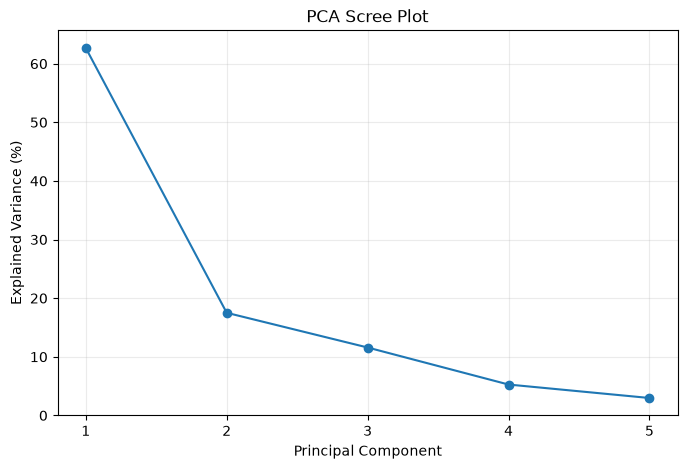

In [12]:
# ============================================================
# PCA SCREE PLOT
# ============================================================

components = np.arange(
    1,
    len(pca_features) + 1
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    components,
    pca_full.explained_variance_ratio_ * 100,
    marker="o"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Explained Variance (%)"
)

plt.title(
    "PCA Scree Plot"
)

plt.xticks(
    components
)

plt.grid(
    alpha=0.25
)

plt.show()

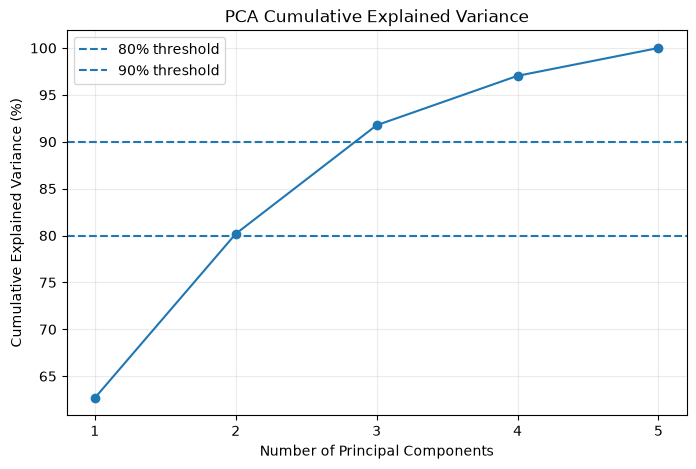

In [13]:
# ============================================================
# PCA CUMULATIVE EXPLAINED VARIANCE
# ============================================================

cumulative_variance = (
    np.cumsum(
        pca_full.explained_variance_ratio_
    ) * 100
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=80,
    linestyle="--",
    label="80% threshold"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="90% threshold"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "PCA Cumulative Explained Variance"
)

plt.xticks(
    components
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.show()

## 6. Principal Component Loadings

Explained variance indicates how much information each principal component retains, but it does not explain what the components represent.

Component loadings are therefore examined to identify which original variables contribute most strongly to each principal component.

The magnitude of a loading indicates the strength of the relationship between a feature and a component, while its sign indicates direction.

Component labels are assigned only after examining these loadings rather than being assumed in advance.

In [14]:
# ============================================================
# PCA COMPONENT LOADINGS
# ============================================================

pca_loadings = pd.DataFrame(
    pca_full.components_.T,
    index=pca_features,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(pca_features) + 1
        )
    ]
)


print("PCA COMPONENT LOADINGS")
print("=" * 90)

display(
    pca_loadings.style.format(
        "{:.3f}"
    )
)

PCA COMPONENT LOADINGS


,PC1,PC2,PC3,PC4,PC5
log1p_want_to_read_count,0.513,-0.247,-0.008,-0.439,-0.695
log1p_currently_reading_count,0.512,-0.254,-0.107,-0.389,0.714
log1p_already_read_count,0.482,-0.332,-0.072,0.807,-0.035
log1p_edition_count,0.371,0.493,0.783,0.053,0.056
book_age_from_first_publish,0.324,0.722,-0.608,0.048,-0.041


In [15]:
# ============================================================
# RANKED PCA LOADINGS
# ============================================================

for component in [
    "PC1",
    "PC2",
    "PC3"
]:

    ranked = (
        pca_loadings[
            [component]
        ]
        .assign(
            absolute_loading=lambda x:
                x[component].abs()
        )
        .sort_values(
            "absolute_loading",
            ascending=False
        )
    )

    print(
        f"\n{component} — "
        f"Ranked Feature Loadings"
    )

    print("-" * 70)

    display(
        ranked.style.format({
            component: "{:.3f}",
            "absolute_loading": "{:.3f}"
        })
    )


PC1 — Ranked Feature Loadings
----------------------------------------------------------------------


,PC1,absolute_loading
log1p_want_to_read_count,0.513,0.513
log1p_currently_reading_count,0.512,0.512
log1p_already_read_count,0.482,0.482
log1p_edition_count,0.371,0.371
book_age_from_first_publish,0.324,0.324



PC2 — Ranked Feature Loadings
----------------------------------------------------------------------


,PC2,absolute_loading
book_age_from_first_publish,0.722,0.722
log1p_edition_count,0.493,0.493
log1p_already_read_count,-0.332,0.332
log1p_currently_reading_count,-0.254,0.254
log1p_want_to_read_count,-0.247,0.247



PC3 — Ranked Feature Loadings
----------------------------------------------------------------------


,PC3,absolute_loading
log1p_edition_count,0.783,0.783
book_age_from_first_publish,-0.608,0.608
log1p_currently_reading_count,-0.107,0.107
log1p_already_read_count,-0.072,0.072
log1p_want_to_read_count,-0.008,0.008


In [16]:
# ============================================================
# PCA COMPONENT SCORES
# ============================================================

pca_scores = pd.DataFrame(
    X_pca_full[:, :3],
    columns=[
        "PC1",
        "PC2",
        "PC3"
    ],
    index=pca_books.index
)


pca_books_with_scores = (
    pca_books[
        [
            "book_id",
            "canonical_title",
            "source_group"
        ]
    ]
    .join(pca_scores)
)


print("PCA BOOK SCORES")
print("=" * 90)

display(
    pca_books_with_scores.head(10)
)


assert (
    len(pca_books_with_scores)
    == 805
)

assert (
    pca_books_with_scores[
        ["PC1", "PC2", "PC3"]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)


print(
    "\n✓ PCA component scores generated "
    "for all 805 books."
)

PCA BOOK SCORES


,book_id,canonical_title,source_group,PC1,PC2,PC3
0,BOOK00001,Principle-Centered Leadership,Open Library only,3.629803,-0.267180,0.384977
1,BOOK00002,Leadership in Organizations,Open Library only,2.520035,1.120787,0.455492
2,BOOK00003,Kepemimpinan =,Open Library only,2.105516,-0.835645,-2.165558
3,BOOK00004,Spiritual leadership,Open Library only,2.593626,0.889221,-1.135467
4,BOOK00005,Leadership,Open Library only,1.679115,-0.717662,-0.301962
5,BOOK00006,The 21 Irrefutable Laws of Leadership,Open Library only,3.824161,-1.373698,0.202071
6,BOOK00007,Leadership,Open Library only,1.246249,-0.323540,0.268961
7,BOOK00008,Leadership and performance beyond expectations,Open Library only,2.847212,-1.578722,-1.980754
8,BOOK00009,A Higher Loyalty,Open Library only,0.971922,-1.318330,1.054449
9,BOOK00010,Leadership and Self Deception,Open Library only,2.928912,-0.307192,1.251008



✓ PCA component scores generated for all 805 books.


## 7. PCA Component Selection and Interpretation

Three principal components are retained.

The first two components explain 80.18% of the total standardized variance. Adding the third component increases cumulative explained variance to 91.76%.

Although two components satisfy an 80% variance-retention threshold, the third component contributes an additional 11.58% and has a distinct, interpretable loading structure. Therefore, three components provide a stronger balance between dimensionality reduction, information retention, and interpretability.

### PC1 — Reader Engagement and Reach

PC1 explains 62.68% of total variance.

Its strongest positive loadings are:

- want-to-read activity: 0.513
- currently-reading activity: 0.512
- already-read activity: 0.482
- edition count: 0.371
- book age: 0.324

All five variables move in the same direction. PC1 therefore summarizes a broad dimension of reader engagement and bibliographic reach.

### PC2 — Longevity vs. Current Engagement

PC2 explains 17.50% of total variance.

Its strongest loading is book age (0.722), followed by edition count (0.493). The three reader-engagement variables load in the opposite direction.

PC2 therefore distinguishes books associated more strongly with longevity and edition history from books associated more strongly with reader-engagement activity.

The sign of a PCA component is mathematically arbitrary; interpretation is based on the relative direction and magnitude of the loadings.

### PC3 — Edition Reach vs. Longevity

PC3 explains 11.58% of total variance.

Edition count has a strong positive loading (0.783), while book age has a strong loading in the opposite direction (-0.608). Reader-engagement variables contribute relatively little.

PC3 therefore captures a bibliographic dimension contrasting edition proliferation with publication longevity.

### Final PCA Representation

The original five standardized numerical variables are reduced to three principal components while retaining 91.76% of their total variance.

This PCA applies only to the 805-book numerical analytical subset and should not be interpreted as representing the complete 2,067-book catalogue.

In [17]:
# ============================================================
# FINAL THREE-COMPONENT PCA MODEL
# ============================================================

pca_final = PCA(
    n_components=3
)

X_pca_final = pca_final.fit_transform(
    X_pca_scaled
)


final_pca_variance = pd.DataFrame({
    "component": [
        "PC1",
        "PC2",
        "PC3"
    ],
    "explained_variance_pct":
        pca_final.explained_variance_ratio_ * 100,

    "cumulative_variance_pct":
        np.cumsum(
            pca_final.explained_variance_ratio_
        ) * 100
})


print("FINAL THREE-COMPONENT PCA")
print("=" * 90)

print(
    "Original dimensions:",
    X_pca_scaled.shape
)

print(
    "Reduced dimensions:",
    X_pca_final.shape
)

display(
    final_pca_variance.style.format({
        "explained_variance_pct": "{:.2f}%",
        "cumulative_variance_pct": "{:.2f}%"
    })
)


assert X_pca_final.shape == (
    805,
    3
)

assert (
    pca_final.explained_variance_ratio_.sum()
    > 0.90
)


print(
    f"\nVariance retained: "
    f"{pca_final.explained_variance_ratio_.sum() * 100:.2f}%"
)

print(
    "✓ Final PCA representation validated."
)

FINAL THREE-COMPONENT PCA
Original dimensions: (805, 5)
Reduced dimensions: (805, 3)


,component,explained_variance_pct,cumulative_variance_pct
0,PC1,62.68%,62.68%
1,PC2,17.50%,80.18%
2,PC3,11.58%,91.76%



Variance retained: 91.76%
✓ Final PCA representation validated.


In [18]:
# ============================================================
# FINAL PCA BOOK REPRESENTATION
# ============================================================

pca_output = pca_books[
    [
        "book_id",
        "canonical_title",
        "source_group"
    ]
].copy()


pca_output[
    [
        "PC1",
        "PC2",
        "PC3"
    ]
] = X_pca_final


print("FINAL PCA BOOK REPRESENTATION")
print("=" * 90)

print(
    "Shape:",
    pca_output.shape
)

display(
    pca_output.head(10)
)


assert len(pca_output) == 805

assert (
    pca_output["book_id"].nunique()
    == 805
)

assert (
    pca_output[
        ["PC1", "PC2", "PC3"]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)


print(
    "\n✓ Final PCA book representation created."
)

FINAL PCA BOOK REPRESENTATION
Shape: (805, 6)


,book_id,canonical_title,source_group,PC1,PC2,PC3
0,BOOK00001,Principle-Centered Leadership,Open Library only,3.629803,-0.267180,0.384977
1,BOOK00002,Leadership in Organizations,Open Library only,2.520035,1.120787,0.455492
2,BOOK00003,Kepemimpinan =,Open Library only,2.105516,-0.835645,-2.165558
3,BOOK00004,Spiritual leadership,Open Library only,2.593626,0.889221,-1.135467
4,BOOK00005,Leadership,Open Library only,1.679115,-0.717662,-0.301962
5,BOOK00006,The 21 Irrefutable Laws of Leadership,Open Library only,3.824161,-1.373698,0.202071
6,BOOK00007,Leadership,Open Library only,1.246249,-0.323540,0.268961
7,BOOK00008,Leadership and performance beyond expectations,Open Library only,2.847212,-1.578722,-1.980754
8,BOOK00009,A Higher Loyalty,Open Library only,0.971922,-1.318330,1.054449
9,BOOK00010,Leadership and Self Deception,Open Library only,2.928912,-0.307192,1.251008



✓ Final PCA book representation created.


## 8. Truncated SVD for Textual Features

The NLP stage produced two high-dimensional sparse TF-IDF representations:

- **Core TF-IDF:** 2,067 books × 1,816 textual features
- **Enriched TF-IDF:** 2,067 books × 5,130 textual features

Standard PCA is not applied to these matrices because PCA generally requires centering the feature matrix, which would destroy the computational advantages of sparse TF-IDF data.

Instead, **Truncated Singular Value Decomposition (Truncated SVD)** is used.

When applied to document-term matrices, this approach is commonly associated with **Latent Semantic Analysis (LSA)**.

Truncated SVD seeks lower-dimensional latent dimensions that summarize patterns of term co-occurrence across books.

Potential benefits include:

- reducing thousands of TF-IDF dimensions;
- identifying latent semantic structure;
- reducing noise and redundancy;
- improving computational efficiency for clustering;
- providing dense representations suitable for downstream unsupervised learning.

The Core and Enriched TF-IDF representations are evaluated separately because the Enriched representation contains substantially more semantic metadata but also greater source-related metadata asymmetry.

In [19]:
# ============================================================
# TRUNCATED SVD COMPONENT SEARCH
# ============================================================

svd_component_candidates = [
    10,
    25,
    50,
    75,
    100,
    150,
    200
]


svd_results = []


for representation_name, matrix in [
    ("Core", core_tfidf),
    ("Enriched", enriched_tfidf)
]:

    print(
        f"\nEvaluating {representation_name} TF-IDF..."
    )

    for n_components in svd_component_candidates:

        svd_test = TruncatedSVD(
            n_components=n_components,
            random_state=42
        )

        svd_test.fit(matrix)

        cumulative_variance = (
            svd_test
            .explained_variance_ratio_
            .sum()
        )

        svd_results.append({
            "representation":
                representation_name,

            "components":
                n_components,

            "explained_variance_pct":
                cumulative_variance * 100
        })

        print(
            f"{n_components:>3} components: "
            f"{cumulative_variance * 100:.2f}%"
        )


svd_component_summary = pd.DataFrame(
    svd_results
)


print("\nSVD COMPONENT SEARCH")
print("=" * 90)

display(
    svd_component_summary.style.format({
        "explained_variance_pct": "{:.2f}%"
    })
)


Evaluating Core TF-IDF...
 10 components: 8.77%
 25 components: 16.69%
 50 components: 24.19%
 75 components: 29.80%
100 components: 34.66%
150 components: 42.81%
200 components: 49.43%

Evaluating Enriched TF-IDF...
 10 components: 7.37%
 25 components: 12.95%
 50 components: 19.34%
 75 components: 24.27%
100 components: 28.65%
150 components: 35.94%
200 components: 41.95%

SVD COMPONENT SEARCH


,representation,components,explained_variance_pct
0,Core,10,8.77%
1,Core,25,16.69%
2,Core,50,24.19%
3,Core,75,29.80%
4,Core,100,34.66%
5,Core,150,42.81%
6,Core,200,49.43%
7,Enriched,10,7.37%
8,Enriched,25,12.95%
9,Enriched,50,19.34%


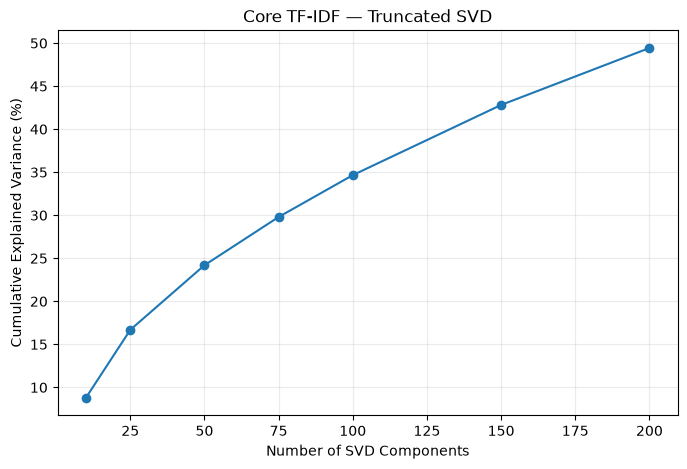

In [20]:
# ============================================================
# CORE SVD EXPLAINED VARIANCE
# ============================================================

core_svd_search = (
    svd_component_summary[
        svd_component_summary[
            "representation"
        ] == "Core"
    ]
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    core_svd_search["components"],
    core_svd_search[
        "explained_variance_pct"
    ],
    marker="o"
)

plt.xlabel(
    "Number of SVD Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "Core TF-IDF — Truncated SVD"
)

plt.grid(
    alpha=0.25
)

plt.show()

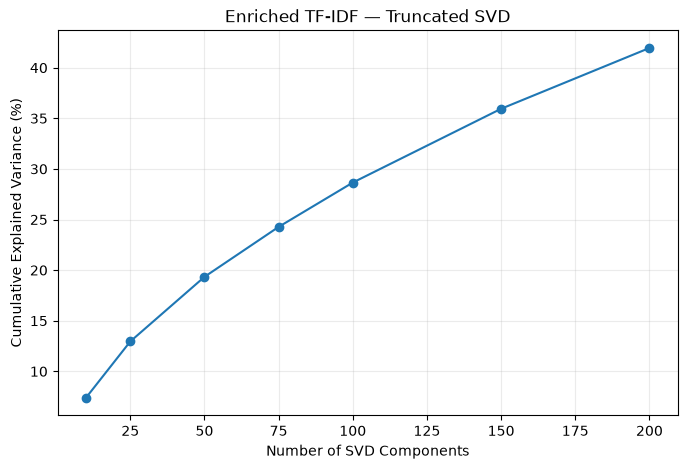

In [21]:
# ============================================================
# ENRICHED SVD EXPLAINED VARIANCE
# ============================================================

enriched_svd_search = (
    svd_component_summary[
        svd_component_summary[
            "representation"
        ] == "Enriched"
    ]
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    enriched_svd_search["components"],
    enriched_svd_search[
        "explained_variance_pct"
    ],
    marker="o"
)

plt.xlabel(
    "Number of SVD Components"
)

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "Enriched TF-IDF — Truncated SVD"
)

plt.grid(
    alpha=0.25
)

plt.show()

## 9. Selection of SVD Dimensionality

Unlike the numerical PCA, the TF-IDF representations distribute variance across a large number of sparse lexical dimensions.

At 200 components:

- Core TF-IDF retains 49.43% of variance.
- Enriched TF-IDF retains 41.95% of variance.

A fixed variance threshold such as 80% or 90% is therefore not used as the sole selection criterion.

Because the final application is a content-based recommendation system, the reduced representation should preserve meaningful similarity relationships between books.

Candidate SVD representations of 100, 150, and 200 components are therefore evaluated using:

1. cumulative explained variance;
2. reduction in dimensionality;
3. preservation of cosine-similarity structure.

The objective is to identify a compact representation that preserves useful semantic relationships without retaining unnecessary dimensionality.

In [22]:
# ============================================================
# SVD SIMILARITY-PRESERVATION EVALUATION
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr


SVD_CANDIDATES = [
    100,
    150,
    200
]

RANDOM_STATE = 42
SAMPLE_SIZE = 300


rng = np.random.default_rng(
    RANDOM_STATE
)

sample_indices = np.sort(
    rng.choice(
        core_tfidf.shape[0],
        size=SAMPLE_SIZE,
        replace=False
    )
)


def upper_triangle_values(matrix):
    """
    Extract unique off-diagonal pairwise
    similarities from a square matrix.
    """
    indices = np.triu_indices_from(
        matrix,
        k=1
    )

    return matrix[indices]


similarity_results = []


for representation_name, matrix in [
    ("Core", core_tfidf),
    ("Enriched", enriched_tfidf)
]:

    print(
        f"\nEvaluating {representation_name}..."
    )

    # Original TF-IDF similarities
    original_sample = matrix[
        sample_indices
    ]

    original_similarity = cosine_similarity(
        original_sample
    )

    original_pairs = upper_triangle_values(
        original_similarity
    )


    for n_components in SVD_CANDIDATES:

        svd_model = TruncatedSVD(
            n_components=n_components,
            random_state=RANDOM_STATE
        )

        reduced_matrix = (
            svd_model.fit_transform(
                matrix
            )
        )

        reduced_sample = reduced_matrix[
            sample_indices
        ]

        reduced_similarity = cosine_similarity(
            reduced_sample
        )

        reduced_pairs = upper_triangle_values(
            reduced_similarity
        )


        rho, p_value = spearmanr(
            original_pairs,
            reduced_pairs
        )


        similarity_results.append({
            "representation":
                representation_name,

            "components":
                n_components,

            "explained_variance_pct":
                svd_model
                .explained_variance_ratio_
                .sum()
                * 100,

            "similarity_spearman_rho":
                rho,

            "p_value":
                p_value
        })


        print(
            f"{n_components:>3} components | "
            f"variance="
            f"{svd_model.explained_variance_ratio_.sum() * 100:.2f}% | "
            f"similarity rho={rho:.4f}"
        )


svd_similarity_summary = pd.DataFrame(
    similarity_results
)


print("\nSVD SIMILARITY PRESERVATION")
print("=" * 90)

display(
    svd_similarity_summary.style.format({
        "explained_variance_pct":
            "{:.2f}%",

        "similarity_spearman_rho":
            "{:.4f}",

        "p_value":
            "{:.3e}"
    })
)


Evaluating Core...
100 components | variance=34.66% | similarity rho=0.3716
150 components | variance=42.81% | similarity rho=0.3812
200 components | variance=49.43% | similarity rho=0.3873

Evaluating Enriched...
100 components | variance=28.65% | similarity rho=0.4876
150 components | variance=35.94% | similarity rho=0.5058
200 components | variance=41.95% | similarity rho=0.5158

SVD SIMILARITY PRESERVATION


,representation,components,explained_variance_pct,similarity_spearman_rho,p_value
0,Core,100,34.66%,0.3716,0.000e+00
1,Core,150,42.81%,0.3812,0.000e+00
2,Core,200,49.43%,0.3873,0.000e+00
3,Enriched,100,28.65%,0.4876,0.000e+00
4,Enriched,150,35.94%,0.5058,0.000e+00
5,Enriched,200,41.95%,0.5158,0.000e+00


In [23]:
# ============================================================
# TOP-10 NEIGHBOUR PRESERVATION
# ============================================================

def top_k_neighbors(
    similarity_matrix,
    k=10
):
    """
    Return top-k neighbour indices for each row,
    excluding self-similarity.
    """

    sim = similarity_matrix.copy()

    np.fill_diagonal(
        sim,
        -np.inf
    )

    return np.argsort(
        sim,
        axis=1
    )[:, -k:]


def neighbor_overlap(
    original_neighbors,
    reduced_neighbors
):
    """
    Mean proportion of original neighbours
    retained after dimensionality reduction.
    """

    overlaps = []

    for original, reduced in zip(
        original_neighbors,
        reduced_neighbors
    ):

        overlap = len(
            set(original)
            .intersection(
                set(reduced)
            )
        )

        overlaps.append(
            overlap / len(original)
        )

    return np.mean(overlaps)


neighbor_results = []


for representation_name, matrix in [
    ("Core", core_tfidf),
    ("Enriched", enriched_tfidf)
]:

    original_sample = matrix[
        sample_indices
    ]

    original_similarity = cosine_similarity(
        original_sample
    )

    original_neighbors = top_k_neighbors(
        original_similarity,
        k=10
    )


    for n_components in SVD_CANDIDATES:

        svd_model = TruncatedSVD(
            n_components=n_components,
            random_state=RANDOM_STATE
        )

        reduced_matrix = (
            svd_model.fit_transform(
                matrix
            )
        )

        reduced_sample = reduced_matrix[
            sample_indices
        ]

        reduced_similarity = cosine_similarity(
            reduced_sample
        )

        reduced_neighbors = top_k_neighbors(
            reduced_similarity,
            k=10
        )

        overlap = neighbor_overlap(
            original_neighbors,
            reduced_neighbors
        )


        neighbor_results.append({
            "representation":
                representation_name,

            "components":
                n_components,

            "top10_neighbor_preservation_pct":
                overlap * 100
        })


neighbor_summary = pd.DataFrame(
    neighbor_results
)


print("TOP-10 NEIGHBOUR PRESERVATION")
print("=" * 90)

display(
    neighbor_summary.style.format({
        "top10_neighbor_preservation_pct":
            "{:.2f}%"
    })
)

TOP-10 NEIGHBOUR PRESERVATION


,representation,components,top10_neighbor_preservation_pct
0,Core,100,47.80%
1,Core,150,50.83%
2,Core,200,52.57%
3,Enriched,100,50.57%
4,Enriched,150,55.03%
5,Enriched,200,57.97%


## 10. Final SVD Component Selection

Candidate Truncated SVD representations of 100, 150, and 200 components were evaluated using three criteria:

1. cumulative explained variance;
2. Spearman correlation between original and reduced cosine-similarity structures;
3. preservation of the original Top-10 nearest neighbours.

Within the tested candidate range, 200 components produced the strongest results for both representations.

### Core TF-IDF

At 200 components:

- explained variance: 49.43%;
- similarity preservation (Spearman rho): 0.3873;
- Top-10 neighbour preservation: 52.57%;
- dimensionality reduced from 1,816 to 200.

### Enriched TF-IDF

At 200 components:

- explained variance: 41.95%;
- similarity preservation (Spearman rho): 0.5158;
- Top-10 neighbour preservation: 57.97%;
- dimensionality reduced from 5,130 to 200.

The Enriched representation retains less total variance than the Core representation, but it preserves the original TF-IDF similarity and nearest-neighbour structures more strongly.

This demonstrates why explained variance should not be used as the sole criterion for selecting text dimensionality in a recommendation-system context.

Based on the tested candidate range, **200 SVD components are retained for both Core and Enriched representations**.

This selection should not be interpreted as a globally optimal dimensionality. It is the strongest-performing dimensionality among the evaluated candidates and will be evaluated further through downstream clustering and recommendation performance.

In [24]:
# ============================================================
# FINAL TRUNCATED SVD MODELS
# ============================================================

FINAL_SVD_COMPONENTS = 200
RANDOM_STATE = 42


# ------------------------------------------------------------
# Core
# ------------------------------------------------------------

core_svd_final = TruncatedSVD(
    n_components=FINAL_SVD_COMPONENTS,
    random_state=RANDOM_STATE
)

core_lsa_final = (
    core_svd_final.fit_transform(
        core_tfidf
    )
)


# ------------------------------------------------------------
# Enriched
# ------------------------------------------------------------

enriched_svd_final = TruncatedSVD(
    n_components=FINAL_SVD_COMPONENTS,
    random_state=RANDOM_STATE
)

enriched_lsa_final = (
    enriched_svd_final.fit_transform(
        enriched_tfidf
    )
)


print("FINAL SVD / LSA REPRESENTATIONS")
print("=" * 90)

print(
    "Core:",
    core_tfidf.shape,
    "→",
    core_lsa_final.shape
)

print(
    "Enriched:",
    enriched_tfidf.shape,
    "→",
    enriched_lsa_final.shape
)

print(
    "\nCore variance retained:",
    f"{core_svd_final.explained_variance_ratio_.sum() * 100:.2f}%"
)

print(
    "Enriched variance retained:",
    f"{enriched_svd_final.explained_variance_ratio_.sum() * 100:.2f}%"
)


assert core_lsa_final.shape == (
    2067,
    200
)

assert enriched_lsa_final.shape == (
    2067,
    200
)

assert np.isfinite(
    core_lsa_final
).all()

assert np.isfinite(
    enriched_lsa_final
).all()


print(
    "\n✓ Final Core LSA representation validated."
)

print(
    "✓ Final Enriched LSA representation validated."
)

FINAL SVD / LSA REPRESENTATIONS
Core: (2067, 1816) → (2067, 200)
Enriched: (2067, 5130) → (2067, 200)

Core variance retained: 49.43%
Enriched variance retained: 41.95%

✓ Final Core LSA representation validated.
✓ Final Enriched LSA representation validated.


In [25]:
# ============================================================
# LSA ZERO-VECTOR VALIDATION
# ============================================================

core_lsa_norm = np.linalg.norm(
    core_lsa_final,
    axis=1
)

enriched_lsa_norm = np.linalg.norm(
    enriched_lsa_final,
    axis=1
)


core_lsa_zero = np.isclose(
    core_lsa_norm,
    0
)

enriched_lsa_zero = np.isclose(
    enriched_lsa_norm,
    0
)


print("LSA ZERO-VECTOR AUDIT")
print("=" * 90)

print(
    "Core TF-IDF zero vectors:",
    int(
        (
            np.asarray(
                (core_tfidf != 0)
                .sum(axis=1)
            ).ravel()
            == 0
        ).sum()
    )
)

print(
    "Core LSA zero vectors:",
    core_lsa_zero.sum()
)

print()

print(
    "Enriched TF-IDF zero vectors:",
    int(
        (
            np.asarray(
                (enriched_tfidf != 0)
                .sum(axis=1)
            ).ravel()
            == 0
        ).sum()
    )
)

print(
    "Enriched LSA zero vectors:",
    enriched_lsa_zero.sum()
)


assert core_lsa_zero.sum() == 42
assert enriched_lsa_zero.sum() == 27


print(
    "\n✓ Zero-vector status preserved after SVD."
)

LSA ZERO-VECTOR AUDIT
Core TF-IDF zero vectors: 42
Core LSA zero vectors: 42

Enriched TF-IDF zero vectors: 27
Enriched LSA zero vectors: 27

✓ Zero-vector status preserved after SVD.


In [32]:
# ============================================================
# LOCATE PROCESSED NLP ARTIFACTS
# ============================================================

from pathlib import Path


# PROJECT_DIR should already exist in Notebook 10.
# If it does not, derive it from the current working directory.

if "PROJECT_DIR" not in globals():

    current_path = Path.cwd()

    if current_path.name == "notebooks":
        PROJECT_DIR = current_path.parent
    else:
        PROJECT_DIR = current_path


PROCESSED_DIR = PROJECT_DIR / "data" / "processed"


print("PROJECT DIRECTORY")
print("=" * 90)
print(PROJECT_DIR)


print("\nPROCESSED DIRECTORY")
print("=" * 90)
print(PROCESSED_DIR)


print("\nNLP-RELATED FILES")
print("=" * 90)

nlp_files = sorted(
    PROCESSED_DIR.glob("*nlp*")
)

for path in nlp_files:
    print(path.name)


print("\nALL PROCESSED FILES")
print("=" * 90)

for path in sorted(
    PROCESSED_DIR.glob("*")
):
    print(path.name)


assert PROCESSED_DIR.exists()

print(
    "\n✓ Processed directory located successfully."
)

PROJECT DIRECTORY
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System

PROCESSED DIRECTORY
/Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/data/processed

NLP-RELATED FILES
books_nlp_features.csv
nlp_book_index.csv
nlp_summary.csv

ALL PROCESSED FILES
books_features.csv
books_nlp_features.csv
feature_engineering_summary.csv
leadershipnow_books_clean.csv
nlp_book_index.csv
nlp_summary.csv
open_library_search_clean.csv
open_library_work_enrichment_clean.csv

✓ Processed directory located successfully.


In [33]:
# ============================================================
# LOCATE NOTEBOOK 09 AND FIND CUSTOM ANALYZER
# ============================================================

NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"


notebook_09_files = sorted(
    NOTEBOOKS_DIR.glob("09*.ipynb")
)


print("NOTEBOOK 09 FILES")
print("=" * 90)

for path in notebook_09_files:
    print(path.name)


assert len(notebook_09_files) > 0, (
    "Notebook 09 was not found."
)


NOTEBOOK_09_PATH = notebook_09_files[0]


print(
    "\nUsing:",
    NOTEBOOK_09_PATH
)

NOTEBOOK 09 FILES
09_nlp_analysis.ipynb

Using: /Users/jannoelvero/Documents/Ironhack/Week_11/Leadership_Management_Book_Recommendation_System/notebooks/09_nlp_analysis.ipynb


In [34]:
# ============================================================
# EXTRACT ORIGINAL ANALYZER DEFINITION FROM NOTEBOOK 09
# ============================================================

import json


with open(
    NOTEBOOK_09_PATH,
    "r",
    encoding="utf-8"
) as file:

    notebook_09 = json.load(file)


matching_cells = []


for cell_number, cell in enumerate(
    notebook_09.get("cells", []),
    start=1
):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(
        cell.get("source", [])
    )

    if "boundary_aware_analyzer" in source:

        matching_cells.append(
            (
                cell_number,
                source
            )
        )


print(
    "CELLS CONTAINING "
    "'boundary_aware_analyzer'"
)

print("=" * 90)


for cell_number, source in matching_cells:

    print(
        f"\nNOTEBOOK CELL {cell_number}"
    )

    print("-" * 90)

    print(source)


assert len(matching_cells) > 0, (
    "boundary_aware_analyzer was not found "
    "in Notebook 09."
)


print(
    f"\n✓ Found analyzer reference in "
    f"{len(matching_cells)} code cell(s)."
)

CELLS CONTAINING 'boundary_aware_analyzer'

NOTEBOOK CELL 39
------------------------------------------------------------------------------------------
# ============================================================
# BOUNDARY-AWARE ANALYZER
# ============================================================

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


STOP_WORDS = set(ENGLISH_STOP_WORDS)


def boundary_aware_analyzer(document):
    """
    Generate unigrams and bigrams independently within each
    metadata field.

    Cross-field bigrams are impossible because each field is
    tokenized separately.
    """

    features = []

    # Split document back into independent metadata fields
    fields = document.split(FIELD_BOUNDARY)

    for field in fields:

        # Extract alphabetic tokens of length >= 2
        tokens = re.findall(
            r"\b[a-zA-Z][a-zA-Z'-]+\b",
            field.lower()
        )

        # Standard English stop-word removal
        tokens =

In [35]:
# ============================================================
# FIND EXACT FIELD_BOUNDARY DEFINITION
# ============================================================

for cell_number, cell in enumerate(
    notebook_09.get("cells", []),
    start=1
):

    if cell.get("cell_type") != "code":
        continue

    source = "".join(
        cell.get("source", [])
    )

    if (
        "FIELD_BOUNDARY =" in source
        or "FIELD_BOUNDARY=" in source
    ):

        print(
            f"\nNOTEBOOK CELL {cell_number}"
        )

        print("-" * 90)

        print(source)


NOTEBOOK CELL 37
------------------------------------------------------------------------------------------
# ============================================================
# FIELD-BOUNDARY-AWARE NLP DOCUMENTS
# ============================================================

FIELD_BOUNDARY = "zzfieldboundaryzz"


def field_has_text(value):
    """
    Return True when a text field contains meaningful content.
    """
    
    if pd.isna(value):
        return False

    value = str(value).strip()

    return value.lower() not in {
        "",
        "[]",
        "{}",
        "nan",
        "none",
        "null",
        "na",
        "n/a"
    }


def join_nlp_fields(*fields):
    """
    Normalize independently meaningful text fields and join them
    using an explicit field-boundary marker.
    """

    cleaned_fields = [
        normalize_nlp_text(field)
        for field in fields
        if field_has_text(field)
    ]

    return (
        f" {FIELD_BOUNDARY} "
        .join(clea

In [36]:
# ============================================================
# RESTORE FINAL NOTEBOOK 09 ANALYZER
# ============================================================

import re

from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS
)


FIELD_BOUNDARY = "zzfieldboundaryzz"

STOP_WORDS = set(
    ENGLISH_STOP_WORDS
)


def boundary_aware_analyzer(document):
    """
    Generate Unicode-aware unigrams and bigrams independently
    within each metadata field.

    Cross-field bigrams are prevented by processing each field
    separately.
    """

    features = []

    fields = document.split(
        FIELD_BOUNDARY
    )

    for field in fields:

        # Unicode-aware tokens, minimum length of 2 characters
        tokens = re.findall(
            r"(?u)\b[^\W_][\w'-]+\b",
            field.lower()
        )

        # Remove standard English stop words only.
        # Multilingual vocabulary is deliberately retained.
        tokens = [
            token
            for token in tokens
            if token not in STOP_WORDS
        ]

        # Unigrams
        features.extend(
            tokens
        )

        # Bigrams within the SAME field only
        features.extend(
            [
                f"{tokens[i]} {tokens[i + 1]}"
                for i in range(
                    len(tokens) - 1
                )
            ]
        )

    return features


print(
    "✓ Final Unicode-safe "
    "boundary_aware_analyzer restored."
)

✓ Final Unicode-safe boundary_aware_analyzer restored.


In [37]:
# ============================================================
# VALIDATE RESTORED ANALYZER
# ============================================================

test_document = (
    "Dirección y administración "
    + FIELD_BOUNDARY +
    " José García"
)


test_features = boundary_aware_analyzer(
    test_document
)


print("RESTORED ANALYZER TEST")
print("=" * 90)

print(test_features)


assert "dirección" in test_features
assert "administración" in test_features
assert "josé" in test_features
assert "garcía" in test_features

assert "josé garcía" in test_features

assert (
    "administración josé"
    not in test_features
)


print(
    "\n✓ Unicode preserved."
)

print(
    "✓ Within-field bigrams preserved."
)

print(
    "✓ Cross-field bigrams prevented."
)

RESTORED ANALYZER TEST
['dirección', 'administración', 'dirección administración', 'josé', 'garcía', 'josé garcía']

✓ Unicode preserved.
✓ Within-field bigrams preserved.
✓ Cross-field bigrams prevented.


In [38]:
# ============================================================
# LOAD SAVED TF-IDF VECTORIZERS
# ============================================================

import joblib


core_vectorizer = joblib.load(
    MODELS_DIR /
    "core_tfidf_vectorizer.joblib"
)

enriched_vectorizer = joblib.load(
    MODELS_DIR /
    "enriched_tfidf_vectorizer.joblib"
)


core_terms = np.array(
    core_vectorizer.get_feature_names_out()
)

enriched_terms = np.array(
    enriched_vectorizer.get_feature_names_out()
)


print("TF-IDF VECTORIZERS RECOVERED")
print("=" * 90)

print(
    "Core vocabulary:",
    len(core_terms)
)

print(
    "Core matrix features:",
    core_tfidf.shape[1]
)

print()

print(
    "Enriched vocabulary:",
    len(enriched_terms)
)

print(
    "Enriched matrix features:",
    enriched_tfidf.shape[1]
)


assert len(core_terms) == 1816
assert len(enriched_terms) == 5130

assert (
    len(core_terms)
    == core_tfidf.shape[1]
    == core_svd_final.components_.shape[1]
)

assert (
    len(enriched_terms)
    == enriched_tfidf.shape[1]
    == enriched_svd_final.components_.shape[1]
)


print(
    "\n✓ Core vocabulary aligns with "
    "TF-IDF and SVD."
)

print(
    "✓ Enriched vocabulary aligns with "
    "TF-IDF and SVD."
)

TF-IDF VECTORIZERS RECOVERED
Core vocabulary: 1816
Core matrix features: 1816

Enriched vocabulary: 5130
Enriched matrix features: 5130

✓ Core vocabulary aligns with TF-IDF and SVD.
✓ Enriched vocabulary aligns with TF-IDF and SVD.


In [39]:
# ============================================================
# LATENT SEMANTIC COMPONENT INTERPRETATION
# ============================================================

def display_svd_topics(
    svd_model,
    feature_names,
    n_components=10,
    n_terms=10
):

    rows = []

    for component_idx in range(
        n_components
    ):

        weights = svd_model.components_[
            component_idx
        ]

        top_indices = np.argsort(
            weights
        )[::-1][:n_terms]

        top_terms = feature_names[
            top_indices
        ]

        top_weights = weights[
            top_indices
        ]

        rows.append({
            "component":
                f"LSA_{component_idx + 1}",

            "top_terms":
                ", ".join(
                    top_terms
                ),

            "top_weights":
                ", ".join(
                    f"{weight:.3f}"
                    for weight
                    in top_weights
                )
        })

    return pd.DataFrame(
        rows
    )

In [40]:
# ============================================================
# CORE LSA — TOP TERMS
# ============================================================

core_topics = display_svd_topics(
    svd_model=core_svd_final,
    feature_names=core_terms,
    n_components=10,
    n_terms=10
)


print(
    "CORE LSA — TOP TERMS"
)

print(
    "=" * 100
)

display(
    core_topics
)

CORE LSA — TOP TERMS


,component,top_terms,top_weights
0,LSA_1,"leadership, management, servant leadership, se...","0.709, 0.309, 0.190, 0.189, 0.155, 0.154, 0.14..."
1,LSA_2,"management, human, human resource, resource ma...","0.596, 0.195, 0.174, 0.174, 0.174, 0.164, 0.16..."
2,LSA_3,"emotional, intelligence, emotional intelligenc...","0.594, 0.550, 0.540, 0.066, 0.065, 0.050, 0.04..."
3,LSA_4,"human, human resource, resource management, re...","0.428, 0.402, 0.402, 0.402, 0.145, 0.122, 0.12..."
4,LSA_5,"organizational, behavior, organizational behav...","0.531, 0.525, 0.520, 0.234, 0.091, 0.062, 0.06..."
5,LSA_6,"david, business, strategy, business strategy, ...","0.616, 0.273, 0.211, 0.191, 0.163, 0.162, 0.14..."
6,LSA_7,"servant, servant leadership, david, michael, p...","0.553, 0.553, 0.167, 0.136, 0.099, 0.094, 0.04..."
7,LSA_8,"performance, performance management, business,...","0.422, 0.399, 0.387, 0.307, 0.273, 0.187, 0.11..."
8,LSA_9,"business, strategy, business strategy, operati...","0.376, 0.281, 0.249, 0.182, 0.178, 0.142, 0.13..."
9,LSA_10,"operations, operations management, production,...","0.449, 0.438, 0.153, 0.153, 0.116, 0.111, 0.11..."


In [41]:
# ============================================================
# ENRICHED LSA — TOP TERMS
# ============================================================

enriched_topics = display_svd_topics(
    svd_model=enriched_svd_final,
    feature_names=enriched_terms,
    n_components=10,
    n_terms=10
)


print(
    "ENRICHED LSA — TOP TERMS"
)

print(
    "=" * 100
)

display(
    enriched_topics
)

ENRICHED LSA — TOP TERMS


,component,top_terms,top_weights
0,LSA_1,"management, leadership, business, organization...","0.508, 0.285, 0.246, 0.197, 0.176, 0.160, 0.15..."
1,LSA_2,"leadership, servant, servant leadership, execu...","0.771, 0.183, 0.182, 0.140, 0.121, 0.117, 0.11..."
2,LSA_3,"personnel, personnel management, human, human ...","0.312, 0.287, 0.286, 0.266, 0.265, 0.252, 0.15..."
3,LSA_4,"emotional, intelligence, emotional intelligenc...","0.401, 0.380, 0.363, 0.248, 0.245, 0.243, 0.11..."
4,LSA_5,"emotional, intelligence, emotional intelligenc...","0.393, 0.371, 0.356, 0.124, 0.121, 0.112, 0.11..."
5,LSA_6,"operations, production, operations management,...","0.312, 0.308, 0.285, 0.220, 0.219, 0.201, 0.18..."
6,LSA_7,"project, project management, technology, manag...","0.490, 0.489, 0.080, 0.071, 0.065, 0.064, 0.06..."
7,LSA_8,"david, change, change management, servant, ser...","0.597, 0.276, 0.160, 0.137, 0.136, 0.126, 0.11..."
8,LSA_9,"change, change management, innovation, organiz...","0.435, 0.268, 0.205, 0.201, 0.160, 0.140, 0.13..."
9,LSA_10,"servant, servant leadership, project managemen...","0.481, 0.478, 0.085, 0.084, 0.076, 0.076, 0.06..."


## 11. Interpretation of Latent Semantic Structure

Inspection of the highest-weight terms in the first ten SVD components indicates that the dimensionality-reduced representations retain recognizable semantic structure.

### Core Representation

The Core representation, constructed from book titles and authors, produces latent dimensions associated with themes including:

- leadership and management;
- human resource management;
- emotional intelligence;
- organizational behavior;
- servant leadership;
- performance management;
- business strategy;
- operations management.

Some Core components also contain prominent author-name terms. This is expected because author information is deliberately included in the Core representation.

### Enriched Representation

The Enriched representation, which additionally incorporates subjects and available descriptions, produces latent dimensions associated with themes including:

- leadership;
- personnel and human resource management;
- emotional intelligence;
- operations and production management;
- project management;
- change management;
- innovation;
- servant leadership.

The Enriched representation therefore demonstrates broader semantic structure than the Core title-and-author representation.

Related concepts may appear across multiple SVD components. This is expected because Latent Semantic Analysis produces continuous latent dimensions rather than mutually exclusive topics or clusters.

Component signs and component numbering should not be interpreted as rankings. The components are mathematical latent directions, and their signs are arbitrary.

Overall, the qualitative inspection supports the use of the SVD representations for downstream clustering and semantic analysis.

In [42]:
# ============================================================
# SAVE FINAL PCA ARTIFACTS
# ============================================================

PCA_OUTPUT_PATH = (
    PROCESSED_DIR /
    "pca_book_coordinates.csv"
)

PCA_VARIANCE_PATH = (
    PROCESSED_DIR /
    "pca_explained_variance.csv"
)

PCA_LOADINGS_PATH = (
    PROCESSED_DIR /
    "pca_loadings.csv"
)


# Final component weights
final_pca_weights = pd.DataFrame(
    pca_final.components_.T,
    index=pca_features,
    columns=[
        "PC1",
        "PC2",
        "PC3"
    ]
)

final_pca_weights.index.name = "feature"


pca_output.to_csv(
    PCA_OUTPUT_PATH,
    index=False
)

final_pca_variance.to_csv(
    PCA_VARIANCE_PATH,
    index=False
)

final_pca_weights.to_csv(
    PCA_LOADINGS_PATH
)


joblib.dump(
    pca_scaler,
    MODELS_DIR / "pca_scaler.joblib"
)

joblib.dump(
    pca_final,
    MODELS_DIR / "pca_model.joblib"
)


print("PCA ARTIFACTS SAVED")
print("=" * 90)

print(PCA_OUTPUT_PATH.name)
print(PCA_VARIANCE_PATH.name)
print(PCA_LOADINGS_PATH.name)
print("pca_scaler.joblib")
print("pca_model.joblib")

PCA ARTIFACTS SAVED
pca_book_coordinates.csv
pca_explained_variance.csv
pca_loadings.csv
pca_scaler.joblib
pca_model.joblib


In [43]:
# ============================================================
# SAVE FINAL LSA COORDINATES
# ============================================================

lsa_columns = [
    f"LSA_{i}"
    for i in range(
        1,
        FINAL_SVD_COMPONENTS + 1
    )
]


core_lsa_output = pd.DataFrame(
    core_lsa_final,
    columns=lsa_columns
)

enriched_lsa_output = pd.DataFrame(
    enriched_lsa_final,
    columns=lsa_columns
)


# Preserve exact NLP row-to-book mapping
core_lsa_output.insert(
    0,
    "book_id",
    nlp_index["book_id"].values
)

enriched_lsa_output.insert(
    0,
    "book_id",
    nlp_index["book_id"].values
)


# Explicitly flag books without usable semantic vectors
core_lsa_output.insert(
    1,
    "is_zero_vector",
    core_lsa_zero
)

enriched_lsa_output.insert(
    1,
    "is_zero_vector",
    enriched_lsa_zero
)


assert len(core_lsa_output) == 2067
assert len(enriched_lsa_output) == 2067

assert (
    core_lsa_output["book_id"].values
    == nlp_index["book_id"].values
).all()

assert (
    enriched_lsa_output["book_id"].values
    == nlp_index["book_id"].values
).all()


core_lsa_output.to_csv(
    PROCESSED_DIR /
    "core_lsa_200.csv",
    index=False
)

enriched_lsa_output.to_csv(
    PROCESSED_DIR /
    "enriched_lsa_200.csv",
    index=False
)


print("LSA COORDINATES SAVED")
print("=" * 90)

print(
    "Core:",
    core_lsa_output.shape
)

print(
    "Enriched:",
    enriched_lsa_output.shape
)

print(
    "\nCore zero vectors:",
    core_lsa_output[
        "is_zero_vector"
    ].sum()
)

print(
    "Enriched zero vectors:",
    enriched_lsa_output[
        "is_zero_vector"
    ].sum()
)

LSA COORDINATES SAVED
Core: (2067, 202)
Enriched: (2067, 202)

Core zero vectors: 42
Enriched zero vectors: 27


In [44]:
# ============================================================
# SAVE SVD MODELS AND DIAGNOSTICS
# ============================================================

joblib.dump(
    core_svd_final,
    MODELS_DIR /
    "core_svd_200.joblib"
)

joblib.dump(
    enriched_svd_final,
    MODELS_DIR /
    "enriched_svd_200.joblib"
)


svd_component_summary.to_csv(
    PROCESSED_DIR /
    "svd_component_search.csv",
    index=False
)

svd_similarity_summary.to_csv(
    PROCESSED_DIR /
    "svd_similarity_preservation.csv",
    index=False
)

neighbor_summary.to_csv(
    PROCESSED_DIR /
    "svd_neighbor_preservation.csv",
    index=False
)

core_topics.to_csv(
    PROCESSED_DIR /
    "core_lsa_topic_terms.csv",
    index=False
)

enriched_topics.to_csv(
    PROCESSED_DIR /
    "enriched_lsa_topic_terms.csv",
    index=False
)


print("SVD / LSA ARTIFACTS SAVED")
print("=" * 90)

print("core_svd_200.joblib")
print("enriched_svd_200.joblib")

print("\nDiagnostic tables saved:")
print("svd_component_search.csv")
print("svd_similarity_preservation.csv")
print("svd_neighbor_preservation.csv")
print("core_lsa_topic_terms.csv")
print("enriched_lsa_topic_terms.csv")

SVD / LSA ARTIFACTS SAVED
core_svd_200.joblib
enriched_svd_200.joblib

Diagnostic tables saved:
svd_component_search.csv
svd_similarity_preservation.csv
svd_neighbor_preservation.csv
core_lsa_topic_terms.csv
enriched_lsa_topic_terms.csv


In [45]:
# ============================================================
# NOTEBOOK 10 — FINAL ARTIFACT AUDIT
# ============================================================

expected_artifacts = {
    # PCA models
    "pca_scaler":
        MODELS_DIR / "pca_scaler.joblib",

    "pca_model":
        MODELS_DIR / "pca_model.joblib",

    # PCA outputs
    "pca_coordinates":
        PROCESSED_DIR / "pca_book_coordinates.csv",

    "pca_variance":
        PROCESSED_DIR / "pca_explained_variance.csv",

    "pca_loadings":
        PROCESSED_DIR / "pca_loadings.csv",

    # SVD models
    "core_svd":
        MODELS_DIR / "core_svd_200.joblib",

    "enriched_svd":
        MODELS_DIR / "enriched_svd_200.joblib",

    # LSA coordinates
    "core_lsa":
        PROCESSED_DIR / "core_lsa_200.csv",

    "enriched_lsa":
        PROCESSED_DIR / "enriched_lsa_200.csv",

    # SVD diagnostics
    "svd_search":
        PROCESSED_DIR / "svd_component_search.csv",

    "svd_similarity":
        PROCESSED_DIR / "svd_similarity_preservation.csv",

    "svd_neighbors":
        PROCESSED_DIR / "svd_neighbor_preservation.csv",

    # Semantic interpretation
    "core_topics":
        PROCESSED_DIR / "core_lsa_topic_terms.csv",

    "enriched_topics":
        PROCESSED_DIR / "enriched_lsa_topic_terms.csv"
}


artifact_audit = pd.DataFrame([
    {
        "artifact": name,
        "file": path.name,
        "exists": path.exists()
    }
    for name, path
    in expected_artifacts.items()
])


print("NOTEBOOK 10 — ARTIFACT AUDIT")
print("=" * 90)

display(artifact_audit)


missing_artifacts = artifact_audit.loc[
    ~artifact_audit["exists"],
    "file"
].tolist()


print(
    "\nArtifacts expected:",
    len(artifact_audit)
)

print(
    "Artifacts found:",
    artifact_audit["exists"].sum()
)

print(
    "Artifacts missing:",
    len(missing_artifacts)
)


if missing_artifacts:

    print("\nMISSING FILES:")

    for file in missing_artifacts:
        print("-", file)

else:

    print(
        "\n✓ All Notebook 10 artifacts are present."
    )

NOTEBOOK 10 — ARTIFACT AUDIT


,artifact,file,exists
0,pca_scaler,pca_scaler.joblib,True
1,pca_model,pca_model.joblib,True
2,pca_coordinates,pca_book_coordinates.csv,True
3,pca_variance,pca_explained_variance.csv,True
4,pca_loadings,pca_loadings.csv,True
5,core_svd,core_svd_200.joblib,True
6,enriched_svd,enriched_svd_200.joblib,True
7,core_lsa,core_lsa_200.csv,True
8,enriched_lsa,enriched_lsa_200.csv,True
9,svd_search,svd_component_search.csv,True



Artifacts expected: 14
Artifacts found: 14
Artifacts missing: 0

✓ All Notebook 10 artifacts are present.


In [46]:
# ============================================================
# CHECK AVAILABLE NLP / MODEL ARTIFACTS
# ============================================================

print("MODEL FILES")
print("=" * 90)

for path in sorted(MODELS_DIR.glob("*")):
    print(path.name)


print("\nPROCESSED NLP FILES")
print("=" * 90)

for path in sorted(PROCESSED_DIR.glob("*nlp*")):
    print(path.name)

MODEL FILES
core_svd_200.joblib
core_tfidf_matrix.npz
core_tfidf_vectorizer.joblib
enriched_svd_200.joblib
enriched_tfidf_matrix.npz
enriched_tfidf_vectorizer.joblib
pca_model.joblib
pca_scaler.joblib

PROCESSED NLP FILES
books_nlp_features.csv
nlp_book_index.csv
nlp_summary.csv


In [47]:
# ============================================================
# CHECK CUSTOM ANALYZER AVAILABILITY
# ============================================================

print(
    "boundary_aware_analyzer available:",
    "boundary_aware_analyzer" in globals()
)

print(
    "core_vectorizer available:",
    "core_vectorizer" in globals()
)

print(
    "enriched_vectorizer available:",
    "enriched_vectorizer" in globals()
)

boundary_aware_analyzer available: True
core_vectorizer available: True
enriched_vectorizer available: True


In [48]:
# ============================================================
# LOAD TF-IDF VECTORIZERS FOR LSA INTERPRETATION
# ============================================================

import joblib


core_vectorizer = joblib.load(
    MODELS_DIR / "core_tfidf_vectorizer.joblib"
)

enriched_vectorizer = joblib.load(
    MODELS_DIR / "enriched_tfidf_vectorizer.joblib"
)


core_terms = np.array(
    core_vectorizer.get_feature_names_out()
)

enriched_terms = np.array(
    enriched_vectorizer.get_feature_names_out()
)


print("TF-IDF VOCABULARY VALIDATION")
print("=" * 90)

print(
    "Core terms:",
    len(core_terms)
)

print(
    "Core SVD input features:",
    core_svd_final.components_.shape[1]
)

print()

print(
    "Enriched terms:",
    len(enriched_terms)
)

print(
    "Enriched SVD input features:",
    enriched_svd_final.components_.shape[1]
)


assert (
    len(core_terms)
    == core_svd_final.components_.shape[1]
    == 1816
)

assert (
    len(enriched_terms)
    == enriched_svd_final.components_.shape[1]
    == 5130
)


print(
    "\n✓ Vocabulary and SVD feature dimensions align."
)

TF-IDF VOCABULARY VALIDATION
Core terms: 1816
Core SVD input features: 1816

Enriched terms: 5130
Enriched SVD input features: 5130

✓ Vocabulary and SVD feature dimensions align.


In [49]:
# ============================================================
# INSPECT LATENT SEMANTIC COMPONENTS
# ============================================================

def display_svd_topics(
    svd_model,
    feature_names,
    n_components=10,
    n_terms=10
):

    rows = []

    for component_idx in range(n_components):

        weights = svd_model.components_[
            component_idx
        ]

        top_indices = np.argsort(
            weights
        )[::-1][:n_terms]

        top_terms = feature_names[
            top_indices
        ]

        top_weights = weights[
            top_indices
        ]

        rows.append({
            "component":
                f"LSA_{component_idx + 1}",

            "top_terms":
                ", ".join(top_terms),

            "top_weights":
                ", ".join(
                    f"{weight:.3f}"
                    for weight in top_weights
                )
        })

    return pd.DataFrame(rows)

In [50]:
# ============================================================
# CORE LATENT SEMANTIC COMPONENTS
# ============================================================

core_topics = display_svd_topics(
    svd_model=core_svd_final,
    feature_names=core_terms,
    n_components=10,
    n_terms=10
)


print("CORE LSA — TOP TERMS")
print("=" * 100)

display(core_topics)

CORE LSA — TOP TERMS


,component,top_terms,top_weights
0,LSA_1,"leadership, management, servant leadership, se...","0.709, 0.309, 0.190, 0.189, 0.155, 0.154, 0.14..."
1,LSA_2,"management, human, human resource, resource ma...","0.596, 0.195, 0.174, 0.174, 0.174, 0.164, 0.16..."
2,LSA_3,"emotional, intelligence, emotional intelligenc...","0.594, 0.550, 0.540, 0.066, 0.065, 0.050, 0.04..."
3,LSA_4,"human, human resource, resource management, re...","0.428, 0.402, 0.402, 0.402, 0.145, 0.122, 0.12..."
4,LSA_5,"organizational, behavior, organizational behav...","0.531, 0.525, 0.520, 0.234, 0.091, 0.062, 0.06..."
5,LSA_6,"david, business, strategy, business strategy, ...","0.616, 0.273, 0.211, 0.191, 0.163, 0.162, 0.14..."
6,LSA_7,"servant, servant leadership, david, michael, p...","0.553, 0.553, 0.167, 0.136, 0.099, 0.094, 0.04..."
7,LSA_8,"performance, performance management, business,...","0.422, 0.399, 0.387, 0.307, 0.273, 0.187, 0.11..."
8,LSA_9,"business, strategy, business strategy, operati...","0.376, 0.281, 0.249, 0.182, 0.178, 0.142, 0.13..."
9,LSA_10,"operations, operations management, production,...","0.449, 0.438, 0.153, 0.153, 0.116, 0.111, 0.11..."


In [51]:
# ============================================================
# ENRICHED LATENT SEMANTIC COMPONENTS
# ============================================================

enriched_topics = display_svd_topics(
    svd_model=enriched_svd_final,
    feature_names=enriched_terms,
    n_components=10,
    n_terms=10
)


print("ENRICHED LSA — TOP TERMS")
print("=" * 100)

display(enriched_topics)

ENRICHED LSA — TOP TERMS


,component,top_terms,top_weights
0,LSA_1,"management, leadership, business, organization...","0.508, 0.285, 0.246, 0.197, 0.176, 0.160, 0.15..."
1,LSA_2,"leadership, servant, servant leadership, execu...","0.771, 0.183, 0.182, 0.140, 0.121, 0.117, 0.11..."
2,LSA_3,"personnel, personnel management, human, human ...","0.312, 0.287, 0.286, 0.266, 0.265, 0.252, 0.15..."
3,LSA_4,"emotional, intelligence, emotional intelligenc...","0.401, 0.380, 0.363, 0.248, 0.245, 0.243, 0.11..."
4,LSA_5,"emotional, intelligence, emotional intelligenc...","0.393, 0.371, 0.356, 0.124, 0.121, 0.112, 0.11..."
5,LSA_6,"operations, production, operations management,...","0.312, 0.308, 0.285, 0.220, 0.219, 0.201, 0.18..."
6,LSA_7,"project, project management, technology, manag...","0.490, 0.489, 0.080, 0.071, 0.065, 0.064, 0.06..."
7,LSA_8,"david, change, change management, servant, ser...","0.597, 0.276, 0.160, 0.137, 0.136, 0.126, 0.11..."
8,LSA_9,"change, change management, innovation, organiz...","0.435, 0.268, 0.205, 0.201, 0.160, 0.140, 0.13..."
9,LSA_10,"servant, servant leadership, project managemen...","0.481, 0.478, 0.085, 0.084, 0.076, 0.076, 0.06..."
